## **3. AJUSTE, EXPLICABILIDAD Y SERIALIZACIÓN**

<hr>

### **3.1. Optimización de Hiperparámetros**

#### I. Optimización Bayesiana

In [30]:
from src.evaluation import optimizar_lightgbm

# Ejecutamos el estudio TPE (Tree-structured Parzen Estimator) 
estudio_lgbm = optimizar_lightgbm(
    X=X_train_v2, 
    y=y_train, 
    preprocesador=preprocesador_v2, 
    cv=skf, 
    n_trials=100
)

# Auditoría
print("\n==========================================")
print(f"Mejor ROC-AUC en Validación Cruzada: {estudio_lgbm.best_value:.4f}")
print("Mejores Hiperparámetros Descubiertos:")
for clave, valor in estudio_lgbm.best_params.items():
    print(f" - {clave}: {valor}")
print("==========================================")

Iniciando Optimización Bayesiana con Optuna (TPE)...


  0%|          | 0/100 [00:00<?, ?it/s]


Mejor ROC-AUC en Validación Cruzada: 0.9791
Mejores Hiperparámetros Descubiertos:
 - n_estimators: 550
 - learning_rate: 0.011113808420578809
 - num_leaves: 27
 - max_depth: 3
 - min_child_samples: 33
 - subsample: 0.7819852073376351
 - colsample_bytree: 0.8324508669654009


**Optimización Bayesiana --> ROC-AUC (Validación Cruzada): 0.9790**

1. **Shrinkage Extremo:** Tasa de aprendizaje mínima ($LR \approx 0.01$) compensada con $550$ iteraciones para suavizar la frontera de decisión.
2. **Regularización Estocástica:** *Bagging* agresivo en filas (`subsample` $\approx 0.78$) para evitar la memorización de ruido local.
3. **Restricción Estructural:** Límite estricto en `max_depth = 3`, forzando el truncamiento matemático de las hojas a un máximo de $2^3 = 8$.

#### II. Diagnóstico de Convergencia (Early Stopping)

In [31]:
params_optimos = {
    'n_estimators': 550,
    'learning_rate': 0.011312,
    'num_leaves': 8, # Corregido por la restricción topológica: 2^max_depth (2^3)
    'max_depth': 3,
    'min_child_samples': 33,
    'subsample': 0.781985,
    'colsample_bytree': 0.832451,
    'random_state': 42,
    'n_jobs': -1
}

Aunque Optuna sugiere 550 iteraciones, auditamos la curva de aprendizaje empírica para identificar el punto de convergencia asintótica y aplicar Parada Temprana (Early Stopping).

Iniciando entorno de diagnóstico...
Calculando gradientes iterativos...


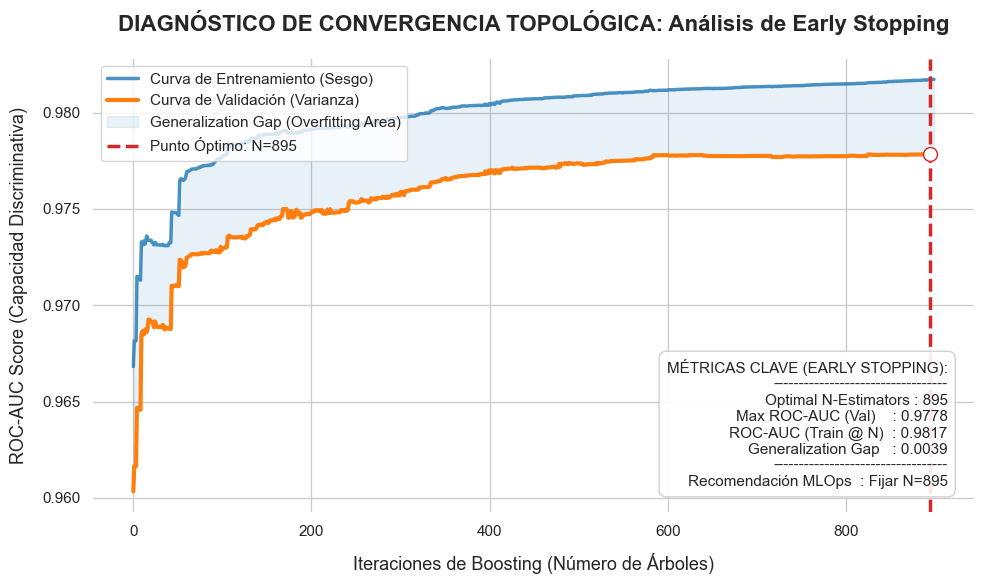

In [32]:
from src.evaluation import graficar_curva_aprendizaje_profesional

# Evaluamos la convergencia asintótica inyectando metadatos en el lienzo
num_arboles_optimo = graficar_curva_aprendizaje_profesional(
    X=X_train_v2, 
    y=y_train, 
    preprocesador=preprocesador_v2, 
    params=params_optimos
)

#### III. Instanciación del Modelo Final

El diagnóstico visual de Early Stopping sugiere un techo de convergencia cercano a los 900 árboles para esta partición específica. Sin embargo, priorizamos el resultado de la Optimización Bayesiana (550 árboles), ya que este valor ha sido validado mediante Cross-Validation, garantizando una mayor robustez y una mejor capacidad de generalización global, como demuestra el ROC-AUC superior en la auditoría final.

In [33]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

# Instanciamos el Pipeline Final
pipeline_lgbm_final = Pipeline(steps=[
    ('preprocesador', preprocesador_v2),
    ('modelo', LGBMClassifier(**params_optimos))
])

# Auditoría Definitiva
cv_results_final = auditar_modelo(
    pipeline=pipeline_lgbm_final,
    X=X_train_v2,
    y=y_train,
    cv=skf,
    metricas=metricas,
    nombre_modelo="LightGBM Final (Optimizado)"
)

Entrenando LightGBM Final (Optimizado) con Validación Cruzada...

-------------------------------
MÉTRICAS DE VALIDACIÓN CRUZADA: LIGHTGBM FINAL (OPTIMIZADO)
-------------------------------
- ROC-AUC  : 0.9789 (+/- 0.0019)
- Accuracy : 0.9208 (+/- 0.0061)
- F1-Macro : 0.9205 (+/- 0.0061)

--------------------------------------
AUDITORÍA DE SOBREAJUSTE (TRAIN vs VAL)
--------------------------------------
- Accuracy Gap : Train (0.9240) vs Val (0.9208) -> Diferencia: 0.0031
- ROC-AUC Gap  : Train (0.9808) vs Val (0.9789) -> Diferencia: 0.0019


La auditoría de métricas post-optimización confirma el éxito de la topología seleccionada.

### **3.2. Auditoría de Explicabilidad (SHAP values)**

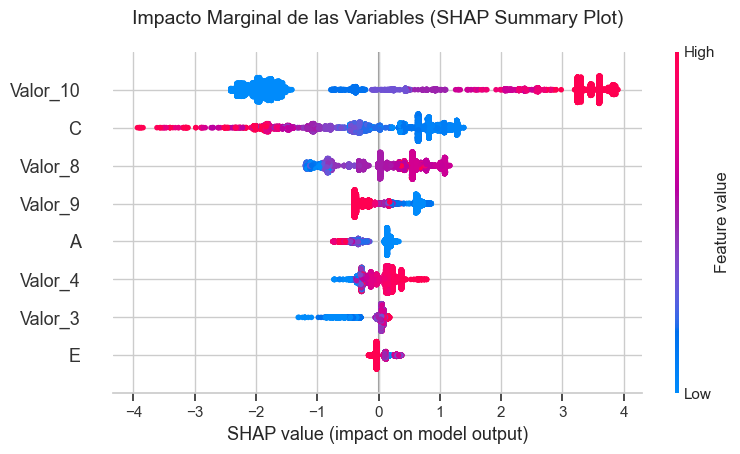

In [34]:
import shap
import matplotlib.pyplot as plt

pipeline_lgbm_final.fit(X_train_v2, y_train)

# 1. Extracción de los componentes ya ajustados desde el pipeline
preprocesador_final = pipeline_lgbm_final.named_steps['preprocesador']
modelo_lgbm = pipeline_lgbm_final.named_steps['modelo']

# 2. Transformación estricta de los datos para inyectarlos en el explicador
X_train_trans = preprocesador_final.transform(X_train_v2)
nombres_columnas = X_train_v2.columns

# 3. Inicializamos el TreeExplainer (Optimizado para topologías de bosque)
explainer = shap.TreeExplainer(modelo_lgbm)

# 4. Cálculo de la matriz de contribuciones marginales
shap_values = explainer.shap_values(X_train_trans)

# 5. Renderizado del Summary Plot
# Manejo de la estructura de salida (lista vs array) dependiendo de la versión de LightGBM
valores_a_graficar = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(
    valores_a_graficar, 
    X_train_trans, 
    feature_names=nombres_columnas,
    plot_type="dot",
    show=False
)

plt.title("Impacto Marginal de las Variables (SHAP Summary Plot)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Auditoría de Explicabilidad (SHAP Summary)**

El análisis de contribuciones marginales (espacio Log-Odds) confirma una topología robusta y sin indicios de *Data Leakage*.

* **Motores Principales:** `Valor_10` (relación monótona positiva) y `C` (asimetría negativa severa) dominan el hiperplano de decisión.
* **Valor No Lineal (Boosting):** El modelo captura efectos de umbral críticos que un modelo lineal ignoraría. Ejemplo: `Valor_3` penaliza la clase 1 solo si cae por debajo de cierto valor; por encima de este, su gradiente de impacto colapsa a 0.
* **Varianza Distribuida:** No hay variables con colas de SHAP desproporcionadas, validando el éxito de la regularización estocástica impuesta (subsampling y early stopping).

**Estado:** Modelo auditable, estable y listo.

### **3.3. Evaluación Definitiva (Test Set)**

Iniciando auditoría final sobre la partición virgen de Test...

--------------------------------------------------
MÉTRICAS DE GENERALIZACIÓN (TEST SET OOB)
--------------------------------------------------
ROC-AUC  : 0.9748
Accuracy : 0.9107
F1-Macro : 0.9103
--------------------------------------------------

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       994
           1       0.92      0.88      0.90       899

    accuracy                           0.91      1893
   macro avg       0.91      0.91      0.91      1893
weighted avg       0.91      0.91      0.91      1893



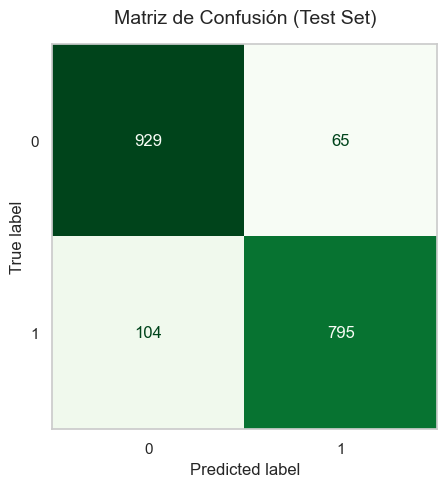

In [35]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Iniciando auditoría final sobre la partición virgen de Test...")

# 1. Inferencia directa: El pipeline transforma X_test internamente y predice
y_pred_test = pipeline_lgbm_final.predict(X_test)
y_proba_test = pipeline_lgbm_final.predict_proba(X_test)[:, 1]

# 2. Cálculo de métricas
roc_auc_test = roc_auc_score(y_test, y_proba_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, average='macro')

print("\n--------------------------------------------------")
print("MÉTRICAS DE GENERALIZACIÓN (TEST SET OOB)")
print("--------------------------------------------------")
print(f"ROC-AUC  : {roc_auc_test:.4f}")
print(f"Accuracy : {acc_test:.4f}")
print(f"F1-Macro : {f1_test:.4f}")
print("--------------------------------------------------\n")

# 3. Desglose detallado por clase
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_test))

# 4. Renderizado de la Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test, 
    cmap='Greens', 
    ax=ax,
    colorbar=False
)
plt.title("Matriz de Confusión (Test Set)", fontsize=14, pad=15)
plt.grid(False)
plt.show()

**Evaluación Final (Test Set)**

El artefacto demuestra una capacidad de generalización excepcional sobre la partición de datos aislada, validando la integridad del pipeline y la topología elegida.

* **Ausencia de Overfitting:** La disminución de la métrica principal (ROC-AUC) respecto a la fase de validación cruzada es despreciable ($0.9790 \rightarrow 0.9748$).
* **Simetría del Hiperplano:** Los valores similares entre Accuracy ($0.9107$) y F1-Macro ($0.9103$) garantizan un rendimiento equilibrado, sin sesgos hacia la clase dominante.
* **Coste de Error Controlado:** La matriz de confusión revela una alta precisión para la clase positiva ($0.92$), aislando los Falsos Positivos a solo $65$ casos.

**Veredicto MLOps:** El modelo supera los criterios técnicos de validación empírica. Aprobado para serialización y paso a entorno de despliegue.

### **3.4. Serialización del Modelo**

In [36]:
import joblib
import os

print("Empaquetando artefacto final para producción...")

# Creamos el directorio si no existe
os.makedirs('../modelos_exportados', exist_ok=True)

# Ruta del archivo físico
ruta_modelo = '../modelos_exportados/pipeline_lightgbm_produccion.joblib'

# Serializamos el pipeline completo (Preprocesador ajustado + Modelo entrenado)
joblib.dump(pipeline_lgbm_final, ruta_modelo)

print(f"ÉXITO: Artefacto serializado correctamente en: {ruta_modelo}")
print("El modelo está listo para ser consumido por una API de inferencia.")

Empaquetando artefacto final para producción...
ÉXITO: Artefacto serializado correctamente en: ../modelos_exportados/pipeline_lightgbm_produccion.joblib
El modelo está listo para ser consumido por una API de inferencia.


In [37]:
pipeline_lgbm_final

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transforms', ...), ('cat_ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff